# Photosynthesis, Light, Life: Linear Algebra + a Differential Equation + ML

Energy absorbed by a chlorophyll molecule hops between pigments by **Forster
resonance energy transfer (FRET)** before it reaches the reaction center.
Population dynamics among the chromophores are a textbook linear ODE,

$$\frac{d\vec p}{dt} = K \vec p,$$

which makes this one biological system three things at once:

1. **Linear algebra** -- $K$'s eigenvalues are the system's normal decay
   modes, the same "turn a differential operator into a matrix eigenvalue
   problem" move as `dgs.bessel_linalg`.
2. **A differential equation** -- solved in closed form via
   eigendecomposition, not a numerical integrator.
3. **Machine learning in biology** -- given only the *observable*
   fluorescence decay curve (not the hidden chromophore populations), a
   gradient-descent fit recovers the underlying FRET rate -- the real
   inverse problem time-resolved fluorescence spectroscopy solves to measure
   nanometer-scale distances, using the same autograd machinery as
   `dgs.differentiable_optics_tutorial`.

Built from `dgs/photosynthesis_energy_transfer.py`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import photosynthesis_energy_transfer as pet

plt.rcParams["figure.dpi"] = 110


## 1. Forster transfer: the inverse-sixth-power distance law


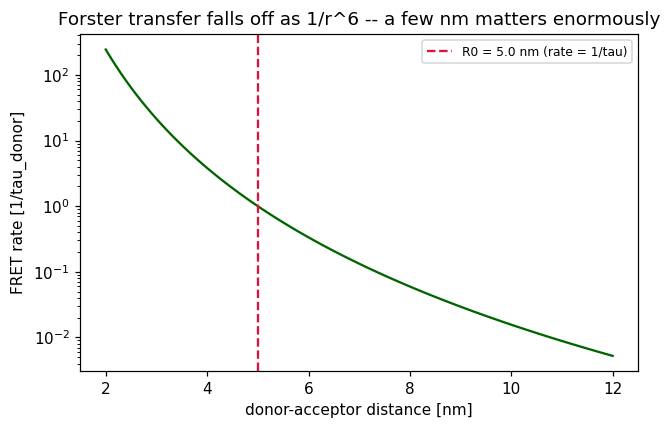

In [2]:
r0 = 5.0  # nm, a typical Forster radius for a chlorophyll pair
r_values = np.linspace(2, 12, 100)
rates = pet.forster_rate(r_values, r0, tau_donor=1.0)

plt.figure(figsize=(6, 4))
plt.semilogy(r_values, rates, color="darkgreen")
plt.axvline(r0, ls="--", color="crimson", label=f"R0 = {r0} nm (rate = 1/tau)")
plt.xlabel("donor-acceptor distance [nm]")
plt.ylabel("FRET rate [1/tau_donor]")
plt.title("Forster transfer falls off as 1/r^6 -- a few nm matters enormously")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. Linear algebra: the rate matrix and its normal modes


In [3]:
K = pet.build_rate_matrix({(0, 1): 2.0}, decay_rates=[0.1, 0.3])
eigvals, eigvecs = pet.eigen_decomposition_modes(K)
print("rate matrix K =")
print(K)
print("\neigenvalues (decay rates of the normal modes):", eigvals)
print("eigenvectors (the normal modes themselves):")
print(eigvecs)


rate matrix K =
[[-2.1  0. ]
 [ 2.  -0.3]]

eigenvalues (decay rates of the normal modes): [-0.3 -2.1]
eigenvectors (the normal modes themselves):
[[ 0.          0.66896473]
 [ 1.         -0.74329415]]


## 3. The differential equation: population dynamics, solved exactly


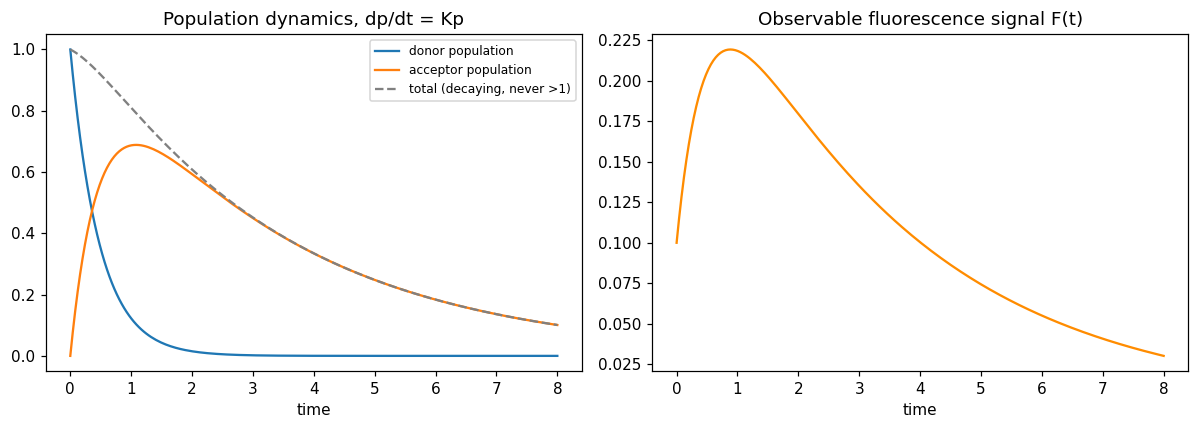

In [4]:
t = np.linspace(0, 8, 200)
p0 = [1.0, 0.0]   # all population starts on the donor
p_t = pet.solve_population_dynamics(K, p0, t)
F = pet.fluorescence_signal(p_t, radiative_rates=[0.1, 0.3])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, p_t[:, 0], label="donor population")
axes[0].plot(t, p_t[:, 1], label="acceptor population")
axes[0].plot(t, p_t.sum(axis=1), "--", color="gray", label="total (decaying, never >1)")
axes[0].set_title("Population dynamics, dp/dt = Kp")
axes[0].set_xlabel("time"); axes[0].legend(fontsize=8)

axes[1].plot(t, F, color="darkorange")
axes[1].set_title("Observable fluorescence signal F(t)")
axes[1].set_xlabel("time")
fig.tight_layout()
plt.show()


## 4. Machine learning in biology: recovering the FRET rate from noisy data

In a real experiment you measure $F(t)$, not the hidden populations. Fit the
unknown transfer rate $k$ by gradient descent on the fluorescence curve
alone -- propagating $p(t)=\exp(Kt)p_0$ via `torch.linalg.matrix_exp`
(differentiable), exactly mirroring `dgs.differentiable_optics_tutorial`'s
gradient-descent phase retrieval, just for a biological rate constant.


true k = 2.0, fit k = 1.9336, final loss = 9.192e-05


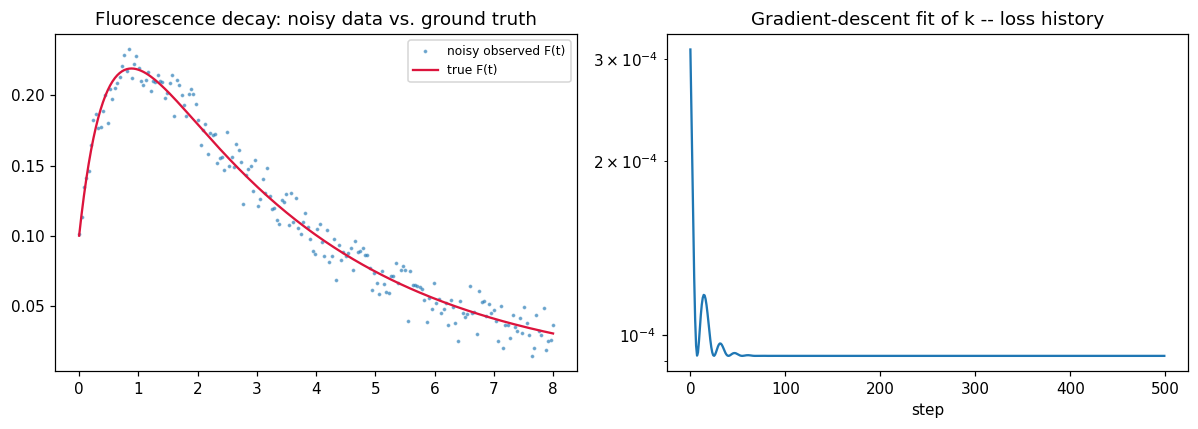

In [5]:
true_k = 2.0
K_true = pet.build_rate_matrix({(0, 1): true_k}, decay_rates=[0.1, 0.3])
p_t_true = pet.solve_population_dynamics(K_true, p0, t)
F_true = pet.fluorescence_signal(p_t_true, [0.1, 0.3])

rng = np.random.default_rng(0)
F_noisy = F_true + 0.01 * rng.standard_normal(F_true.shape)

fit = pet.fit_transfer_rate_from_decay(t, F_noisy, p0, [0.1, 0.3], n_steps=500, lr=0.1)
print(f"true k = {true_k}, fit k = {fit['k_fit']:.4f}, final loss = {fit['loss']:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, F_noisy, ".", ms=3, alpha=0.5, label="noisy observed F(t)")
axes[0].plot(t, F_true, color="crimson", label="true F(t)")
axes[0].set_title("Fluorescence decay: noisy data vs. ground truth")
axes[0].legend(fontsize=8)

axes[1].semilogy(fit["loss_history"])
axes[1].set_title("Gradient-descent fit of k -- loss history")
axes[1].set_xlabel("step")
fig.tight_layout()
plt.show()


## Summary

One physical system, three computational lenses: $K$'s eigendecomposition
*is* linear algebra applied to a transfer-rate graph, $\exp(Kt)$ *is* the
exact solution of the governing differential equation, and recovering $k$
from only the observable fluorescence curve *is* a machine-learning inverse
problem -- solved here with the same gradient-descent-through-a-differentiable-
forward-model approach as the optical phase retrieval earlier in this repo,
just with a biological rate constant standing in for a phase mask.
